## This reproduces Figure 1 of Dai & Li 2006

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from field_decay.compact_objects import NS
from field_decay.accretion import magnetospheric_radius, fastness_parameter, magnetospheric_radius_wang, magnetic_moment
from field_decay.torques import magnetic_torque_dai, magnetic_torque_dai_propeller, accretion_torque_dai, magnetic_torque_wang, accretion_torque

0.7071067811865475
0.09899494936611666


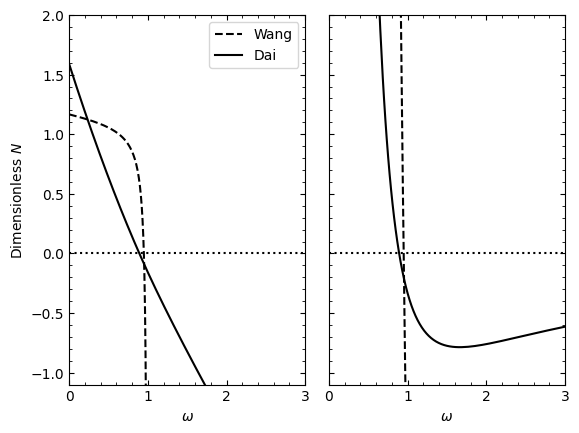

In [2]:
N = 500
Bs = np.geomspace(10**8, 10**14, N)
M_NS = 1.4
ns = NS(P = 15, M_NS=M_NS, chi=0, alpha=0)
mdot = 0.01
Mdot = mdot * ns.MEdd
psi = 1
gamma = 1
delta = 1 / 2**0.5 / gamma
print(delta)
delta = 0.07
xi = 2.0**0.5 * gamma * delta
print(xi)
# Wang approach
mus = magnetic_moment(Bs, ns.R_NS) * 2.
Rmags = np.array([magnetospheric_radius_wang(Mdot, mu, ns.M, ns.Rco, gamma=gamma)[0] for mu in mus])

fastness = fastness_parameter(Rmags, ns.Rco)
Nwang = magnetic_torque_wang(Mdot, Rmags, fastness, ns.M) + accretion_torque(Mdot, Rmags, ns.M)
norm = accretion_torque(Mdot, Rmags, ns.M)

torque_fig,  axes = plt.subplots(1, 2, sharey=True, gridspec_kw={"wspace":0.1})
axes[0].plot(fastness[fastness <1], (Nwang / norm)[fastness <1], 
             label="Wang", ls="--", color="black")
norm = (mus)**2 / (3 * ns.Rco**3)
axes[1].plot(fastness[fastness <1], (Nwang / norm)[fastness <1], 
             ls="--", color="black")

# Dai approach
Rmags = magnetospheric_radius(Mdot, mus, ns.M, psi)
fastness = fastness_parameter(Rmags, ns.Rco)
Ndai = np.where(fastness <= 1, magnetic_torque_dai(mus, Rmags, fastness), 
                magnetic_torque_dai_propeller(mus, Rmags, fastness)) + accretion_torque_dai(Mdot, Rmags, fastness, ns.M, gamma=gamma, delta=delta)
norm = accretion_torque(Mdot, Rmags, ns.M)
axes[0].plot(fastness, Ndai / norm, label="Dai", ls="solid", color="black")
norm = (Bs * ns.R_NS**3)**2 / (3 * ns.Rco**3)
axes[1].plot(fastness, Ndai / norm, ls="solid", color="black")


axes[0].set_ylabel(r"Dimensionless $N$")
for ax in axes:
    ax.set_ylim(-1.1, 2)
    ax.set_xlabel(r"$\omega$")
    ax.set_xlim(0, 3)
    ax.axhline(0, ls=":", color="black")
    ax.minorticks_on()
    ax.tick_params(axis='x', which='both', top=True, direction="in")    # x-axis ticks on top
    ax.tick_params(axis='y', which='both', right=True, direction="in")  # y-axis ticks on right

axes[0].legend()
#torque_fig.savefig("fig1_dai_2006.png", bbox_inches="tight", dpi=300)